# **Pruebas Funcionales del TIF**

Como primer paso se importan las librerías necesarias para procesar y graficar señales fisiológicas, y se cargan las clases principales de la librería TIF.py para representar, describir y analizar señales como EEG, ECG y EMG

In [165]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy
import scipy.signal
from matplotlib.patches import Patch
from scipy.signal import find_peaks, spectrogram
from scipy.signal import hilbert, spectrogram
import json
from TIF import Info, Anotaciones, RawSignal, EEGSignal

---

## **Clase Info**

> La clase Info permite almacenar información relevante sobre una señal fisiológica, como el nombre del experimentador, los datos del sujeto, los nombres y tipos de canales, los canales defectuosos, la frecuencia de muestreo y una descripción del registro.

En este fragmento se definen los metadatos del registro fisiológico. Se crea una lista con los nombres de los canales (`["F2", "F3"]`) y se indica que ambos son de tipo `"ecg"`. Además, se construye un diccionario con la información del sujeto, que incluye su nombre y edad. Estos datos serán utilizados luego para inicializar un objeto de la clase `Info`.

In [2]:
canales = ["F2", "F3"]
tipos_canales = ["ecg"] * len(canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

En este bloque se crea un objeto `Info` con los datos del experimentador, sujeto, canales y descripción. Luego, se accede a la información almacenada utilizando distintos métodos de la clase

In [3]:
info = Info("Juan Acosta", sujeto, canales, tipos_canales, None, "Pruebita", 512)

Si la cantidad de nombres de canales y tipos de canales no coincide, el objeto `Info` lanza un error al momento de su creación.

In [4]:
canales1=["F10","F50",["13"]]
tipos_canales1=["emg"]
sujeto1={"Nombre":"Flor Sosa", "Edad": 24}

In [5]:
info1 = Info("Flor Sosa", sujeto1, canales1,tipos_canales1, None, "Prueba",201)

ValueError: La cantidad de canales y los tipos de canales deben tener la misma longuitud

### **Método** **__ contains __:** Verifica si una clave está presente en el objeto. Devuelve `True` si la clave existe y `False` en caso contrario.

In [6]:
print(info.__contains__("Experimentador"))

True


In [7]:
print(info.__contains__("tipos_canales"))

False


### **Método** **__ getitem __:** Obtiene el valor asociado a una clave. Si la clave existe dentro de info devuelve la clave, sino retorna false

In [8]:
print("Nombre del experimentador:",info.__getitem__("Experimentador"))

Nombre del experimentador: Juan Acosta


In [9]:
print(info.__getitem__("tipos_canales"))

False


### **Método** **__ len __:** Devuelve la cantidad de elementos guardados.

In [10]:
print(info.__len__())

7


### **Método get:** Obtiene el valor asociado a una clave específica del objeto. 

In [11]:
info.get("Frecuencia muestreo")

512

Si la clave existe, devuelve su valor, si no existe, devuelve `False`.

In [52]:
info.get("Electrodo")

False

### **Método keys():** Devuelve la cantidad de elementos guardados.

In [12]:
print(info.keys()) 

['Experimentador', 'Sujeto', 'Nombre canales', 'Tipo canales', 'Canales malos', 'Descripción', 'Frecuencia muestreo']


### **Método item():** Dvuelve una tupla con clave y valor para una clave específica.

In [13]:
print(info.item("Experimentador"))
print(info.item("Nombre canales"))

('Experimentador', 'Juan Acosta')
('Nombre canales', ['F2', 'F3'])


Si al método item() le damos una clave que no existe en el objeto, devuelve simplemente `False`.

In [14]:
print(info.item("Tipo de electrodo"))

False


### **Método rename_channels:**  Permite renombrar canales de forma segura.

In [16]:
print(info.rename_channels("F2", "F1"))
print(info.item("Nombre canales"))

True
('Nombre canales', ['F1', 'F3'])


Si al `método rename_channels()` se le pasa un valor entero como nombre del canal (por ejemplo, 2 en lugar de "F3"), el método intentará buscar ese número en la lista de nombres de canales, y al no encontrarlo retornara un False.

In [17]:
info.rename_channels(2, 5)
print(info.item("Nombre canales"))

print(info.rename_channels(2,5))

('Nombre canales', ['F1', 'F3'])
False


### **Método eliminar_elementos:** Permite eliminar uno o varios elementos de una lista asociada a una clave específica del diccionario interno.

In [18]:
info.eliminar_elementos(key="Nombre canales", elementos=["F3"])
print(info.item("Nombre canales"))

('Nombre canales', ['F1'])


El método `eliminar_elementos` lanza errores si la clave o los elementos a eliminar no existen, lo cual es una forma de protección ante errores silenciosos. Esto se debe a dos validaciones internas

In [19]:
info.eliminar_elementos(key="Canal", elementos=["F1"])

KeyError: "La clave 'Canal' no existe en Info."

In [20]:
info.eliminar_elementos(key="Nombre canales", elementos=["F2"])

ValueError: El elemento 'F2' no se encuentra en la lista asociada a 'Nombre canales'.

---

## **Clase Anotaciones**

> La clase Anotaciones permite almacenar y gestionar eventos asociados a una señal fisiológica, como estímulos, artefactos o respuestas. Cada evento se define por un tiempo de inicio, una duración y una descripción.

Se definen tres listas que representan las propiedades de los eventos: los tiempos de inicio, la duración y la descripción de cada anotación. Estos datos se usarán para crear un objeto de la clase `Anotaciones`.

In [53]:
inicio = [5.0, 12.5, 20.0]
duracion = [2.0, 3.0, 3.5]
descripcion = ['Inicio_Experimento', 'Evento_1', 'Evento_2']

Se crea un objeto de la clase `Anotaciones` utilizando las listas de inicio, duración y descripción definidas previamente. Esto permite almacenar los eventos en forma estructurada para su posterior uso o análisis.

In [54]:
anotaciones = Anotaciones(onset=inicio, duration=duracion, description=descripcion)

Si se proporciona un archivo (file) como argumento, el constructor intentará cargar las anotaciones desde ese archivo usando el método load(). Si el archivo no existe o su formato no es correcto, se generará un error al momento de leerlo.

In [55]:
anotaciones1= Anotaciones()

ValueError: Debe ingresar las anotaciones manualmente o cargarlas a partir de un archivo

Si las listas `onset` y `duration` no tienen la misma cantidad de elementos, el constructor lanza un `ValueError` para evitar que se creen anotaciones inconsistentes.

In [56]:
inicio1 = [5.0, 12.5, 20.0, 5.2]
duracion1 = [2.0, 3.0, 3.5]
descripcion1 = ['Inicio_Experimento', 'Evento_1', 'Evento_2']

anotaciones2 = Anotaciones(onset= inicio1, duration=duracion, description=descripcion)

ValueError: Onset y duration deben tener la misma cantidad de elementos

### **Método get_annotations:** Se utiliza para obtener todas las anotaciones almacenadas en el objeto. El resultado es un DataFrame que muestra, en forma de tabla, los tiempos de inicio, duración y descripción de cada evento.

In [57]:
anotaciones.get_annotations()

,Inicio,Duracion,Descripcion
0,5.0,2.0,Inicio_Experimento
1,12.5,3.0,Evento_1
2,20.0,3.5,Evento_2


### **Método recorte:** Permite limpiar las anotaciones, conservando solo aquellas que ocurren dentro de un intervalo de tiempo específico, y eliminando las que están fuera del rango definido por `tmin` y `tmax`.


In [58]:
anotaciones.recorte(tmin=10, tmax=25)

anotaciones.get_annotations()

,Inicio,Duracion,Descripcion
1,12.5,3.0,Evento_1
2,20.0,3.5,Evento_2


### **Método add:** Permite incorporar una nueva anotación al objeto, siempre que se proporcione como una lista o tupla con exactamente tres elementos: inicio, duración y descripción. 

Si se cumple esta condición, la anotación se agrega al final del DataFrame interno y el método devuelve `True`. En caso contrario, devuelve `False` y no realiza ningún cambio.

In [59]:
nueva_anotacion = [3, 4, "Evento 3"]
anotaciones.add(nueva_anotacion)

True

Verificamos que la nueva anotación haya sido incorporada correctamente al conjunto de eventos almacenados.

In [60]:
anotaciones.get_annotations()

,Inicio,Duracion,Descripcion
1,12.5,3.0,Evento_1
2,3.0,4.0,Evento 3


Si se le pasan parámetros incorrectos, como una lista incompleta o con elementos de más, el método retorna `False`, indicando que la anotación no fue agregada. Esta verificación permite asegurar la consistencia de los datos antes de que se modifiquen.


In [74]:
nueva_anotacion1 = [4, "Evento 3"]
anotaciones.add(nueva_anotacion1)

False

### **Método remove:** Permite eliminar una anotación específica del objeto. Recibe como argumento una lista o tupla con exactamente tres elementos: inicio, duración y descripción. 

Si la anotación coincide con una fila existente, se elimina del DataFrame y el método retorna `True`. Si la anotación no existe o el formato no es válido, retorna `False` y no realiza ninguna modificación.

In [62]:
anotaciones.remove(nueva_anotacion)
anotaciones.get_annotations()

,Inicio,Duracion,Descripcion
1,12.5,3.0,Evento_1


In [ ]:
anotaciones.remove(nueva_anotacion1)

False

### **Método remove:** Se utiliza para eliminar una anotación específica del objeto. Para hacerlo, se debe proporcionar una lista o tupla con tres elementos: el tiempo de inicio, la duración y la descripción del evento que se desea eliminar

Si la anotación coincide exactamente con una fila del DataFrame interno, el método la elimina y retorna `True`. Si la anotación no existe o no tiene el formato correcto (es decir, no tiene tres elementos), el método retorna `False` y no realiza ningún cambio.

In [67]:
nueva_anotacion2 = [2,6, "Evento 4"]
anotaciones.add(nueva_anotacion2)

anotaciones.get_annotations()

,Inicio,Duracion,Descripcion
1,2.0,6.0,Evento 4


In [69]:
anotaciones.remove(nueva_anotacion2)

True

Verificamos que la nueva anotación haya sido removida correctamente al conjunto de eventos almacenados.

In [73]:
anotaciones.get_annotations()

,Inicio,Duracion,Descripcion


Si una anotación no tiene los parámetros correctos, no se añade al objeto. Por lo tanto, para que una anotación pueda ser removida, debe coincidir exactamente con los valores que fueron previamente agregados. Esto hace que simular la eliminación de una anotación inexistente sea poco probable si los datos se controlan correctamente.

In [81]:
nueva_anotacion3 = [2,6, 7, "Evento 5"]
anotaciones.add(nueva_anotacion3)
anotaciones.remove(nueva_anotacion3)

False

### **Método find:** El método `find()` permite buscar una anotación específica dentro del objeto. Recibe como argumento una lista o tupla con tres elementos: inicio, duración y descripción.

Si la anotación existe, devuelve un **DataFrame** con esa fila. Si no se encuentra o si el formato es incorrecto (por ejemplo, si no se pasan exactamente tres elementos), el método retorna `False`.

Este método es útil para localizar eventos concretos y confirmar su presencia en el conjunto de anotaciones.


In [80]:
nueva_anotacion4 = [2,7, "Evento 6"]
anotaciones.add(nueva_anotacion4)
anotaciones.find(nueva_anotacion4)

,Inicio,Duracion,Descripcion
0,2,7,Evento 6


In [76]:
anotaciones.find(nueva_anotacion3)

False

### **Método save:** Permite guardar todas las anotaciones almacenadas en el objeto en un archivo `.csv`. Recibe como argumento el nombre del archivo (sin la extensión), y genera un archivo con tres columnas: `"Inicio"`, `"Duracion"` y `"Descripcion"`.

In [82]:
anotaciones.save("Anotaciones")

### **Método load:** Permite cargar anotaciones desde un archivo `.csv`. Este archivo debe contener tres columnas con los nombres `"Inicio"`, `"Duracion"` y `"Descripcion"`, que representen respectivamente el momento de inicio, la duración y la descripción de cada evento.

Al invocar este método, se lee el archivo con `pandas.read_csv()` y se devuelve un **DataFrame** con los datos cargados. Este método es especialmente útil cuando las anotaciones ya fueron creadas previamente y se quieren reutilizar o analizar en un nuevo entorno.


In [83]:
anotaciones.load("Anotaciones.csv")

,Unnamed: 0,Inicio,Duracion,Descripcion
0,0,2,7,Evento 6


In [85]:
anotaciones_csv = Anotaciones(file="../2. Datos Prueba/eeg/eventos_ejemplo.csv")
anotaciones_csv.get_annotations()

,Inicio,Duracion,Descripcion
0,37.548828,5,IZQUIERDA
1,54.048828,5,DERECHA
2,70.482422,5,DERECHA
3,88.632812,5,DERECHA
4,104.984375,5,IZQUIERDA
5,122.300781,5,IZQUIERDA
6,140.085938,5,DERECHA
7,157.287109,5,DERECHA
8,173.853516,5,DERECHA
9,190.685547,5,DERECHA


---

## **Clase RawSignal**

> La clase RawSignal representa una señal fisiológica cruda (sin procesar), como puede ser EEG, EMG o ECG. Está diseñada para manejar señales en forma de arrays de NumPy con múltiples canales y una frecuencia de muestreo asociada

Se utiliza `np.load()` para cargar un archivo `.npy` que contiene datos de EEG multicanal. El resultado es un array de NumPy que se puede utilizar como entrada para crear un objeto de la clase `RawSignal` o sus derivadas.

In [86]:
eeg_data = np.load("../2. Datos Prueba/eeg/eeg_signal.npy")

In [87]:
eeg_data.shape

(62, 388047)

Se transforma el array de datos EEG en un DataFrame para facilitar su inspección visual. Usando `head()`, se muestran las primeras filas, lo que permite verificar la estructura de la señal, como el número de columnas (canales) y la escala de valores. Esta operación es útil solo como exploración previa y no es necesaria para procesar la señal con `RawSignal`.

In [ ]:
eeg = pd.DataFrame(eeg_data)
eeg.head()

,0,1,2,3,4,5,6,7,8,9,...,388037,388038,388039,388040,388041,388042,388043,388044,388045,388046
0,3.058463,69.378151,512.287476,2046.245483,5376.158691,10384.538086,15923.265625,20547.367188,23392.972656,24475.962891,...,-178.895386,-173.085815,-164.276978,-152.824463,-141.760376,-135.108521,-135.037842,-141.609375,-154.146606,-171.841797
1,2.483788,56.613033,418.650482,1673.291016,4397.784668,8496.500000,13029.791992,16814.097656,19141.298828,20024.503906,...,-34.890717,-32.244675,-26.992029,-20.398066,-14.261873,-10.162393,-8.862572,-10.432716,-14.530706,-20.378460
2,1.720225,39.700825,294.783447,1180.238525,3104.773193,6001.839844,9207.491211,11883.846680,13528.648438,14150.855469,...,-172.516739,-169.558792,-165.001038,-154.812500,-138.597839,-121.553047,-111.058151,-111.978516,-124.081688,-142.575546
3,2.277081,85.158783,690.347961,2849.392334,7594.347656,14776.036133,22754.841797,29451.494141,33609.718750,35234.156250,...,-101.200439,-109.095215,-101.527100,-79.137939,-51.548828,-31.460693,-26.456543,-36.743652,-58.282227,-85.846191
4,2.820107,69.279091,522.174072,2102.081055,5542.711914,10726.230469,16464.289062,21257.328125,24206.724609,25327.796875,...,-33.257740,-30.782782,-25.127575,-17.920855,-11.455353,-7.688463,-7.410977,-10.375611,-15.825042,-22.785292


Primero, se genera una lista de nombres de canales a partir del número 1 al 62, convirtiendo cada número en una cadena de texto. Luego, se crea una lista del mismo largo con el tipo `"eeg"` para cada canal. A continuación, se define un diccionario con los datos del sujeto. Con esta información, se crea el objeto `Info`, que almacena los nombres y tipos de canales, el nombre del experimentador, la frecuencia de muestreo, los canales defectuosos (en este caso, `None`) y una breve descripción.

Finalmente, se imprimen las claves del objeto y los nombres iniciales de los canales para verificar que la información fue cargada correctamente.

In [89]:
canales = range(1,63)

nombre_canales = []
for canal in canales:
    nombre_canales.append(str(canal))
    
# canales = ["F2", "F3", "F4"]
tipos_canales = ["eeg"] * len(nombre_canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

infoo = Info(experimenter="Juan Acosta", subject_info=sujeto, ch_names=nombre_canales, 
        ch_types=tipos_canales, bads=None, description="Pruebita", fm=512)

print("Claves:", infoo.keys())
print("Canales iniciales:", infoo.data["Nombre canales"])

Claves: ['Experimentador', 'Sujeto', 'Nombre canales', 'Tipo canales', 'Canales malos', 'Descripción', 'Frecuencia muestreo']
Canales iniciales: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62']


Se definen listas con los tiempos de inicio, duración y descripción de tres eventos asociados a la señal. Luego, se crea un objeto `Anotaciones` utilizando estas listas como argumentos. El constructor verifica que los datos sean consistentes y construye internamente un DataFrame con las anotaciones, que luego podrán ser visualizadas, modificadas o utilizadas para análisis sincronizado con la señal fisiológica.

In [90]:
inicio = [5.0, 12.5, 20.0]
duracion = [2.0, 3.0, 3.5]
descripcion = ['Inicio_Experimento', 'Evento_1', 'Evento_2']
anotacioness = Anotaciones(onset=inicio, duration=duracion, description=descripcion)

Se genera un objeto `RawSignal` que representa una señal EEG cruda multicanal. Se proporciona como entrada el array de datos, la frecuencia de muestreo (512 Hz), la información de los canales (`infoo`) y las anotaciones (`anotacioness`). El constructor valida que el número de canales coincida con los nombres definidos en el objeto `Info` y que las anotaciones estén dentro del rango temporal de la señal. Luego, al ejecutar `raw_signal.data[1]`, se accede directamente al segundo canal de la señal, devolviendo un array con sus valores en el tiempo.


In [91]:
raw_signal = RawSignal(data=eeg_data, sfreq=512, info=infoo, anotaciones=anotacioness) 
raw_signal.data[1]

array([  2.483788,  56.613033, 418.65048 , ..., -10.432716, -14.530706,
       -20.37846 ], shape=(388047,), dtype=float32)

Si el parámetro data no es un array de NumPy (np.ndarray), el constructor lanza un ValueError indicando que se requiere un arreglo válido para representar la señal. Esto asegura que los métodos de procesamiento funcionen correctamente sobre la estructura de datos esperada.

In [92]:
RawSignal(data=[[1, 2, 3], [4, 5, 6]], sfreq=512)

ValueError: El parámetro 'data' debe ser un array de NumPy (np.ndarray).

El constructor espera un arreglo bidimensional con forma (n_canales, n_muestras). Si se proporciona un array unidimensional, se lanza un ValueError informando que la estructura debe tener dos dimensiones. Esta validación previene errores al acceder a canales o recorrer muestras.

In [93]:
array_1d = np.array([1, 2, 3, 4, 5])
RawSignal(data=array_1d, sfreq=512)

ValueError: El array 'data' debe tener dos dimensiones: (n_canales, n_muestras).

El índice de la primera muestra (first_samp) debe estar dentro del rango de la señal. Si se proporciona un valor negativo o mayor o igual al número total de muestras, se lanza un ValueError indicando que el índice está fuera de rango. Esta verificación garantiza que el desplazamiento temporal de la señal sea coherente

In [95]:
datos = np.random.randn(3, 1000)  # 3 canales, 1000 muestras
RawSignal(data=datos, sfreq=512, first_samp=1000)

ValueError: El índice 'first_samp' está fuera del rango de muestras disponibles.

Si se proporciona un objeto Info que contiene una lista de nombres de canales, su longitud debe coincidir con la cantidad de canales en el array data. Si hay una diferencia entre ambos, se lanza un ValueError informando la discrepancia. Esta validación asegura la integridad entre los datos numéricos y su descripción estructural

In [96]:
datos = np.random.randn(3, 1000)
info = Info("Exp", {"Edad": 25}, ["C1", "C2"], ["eeg", "eeg"], [], "Desc", fm=512)
RawSignal(data=datos, sfreq=512, info=info)

ValueError: La cantidad de canales de la señal (3) no coincide con la cantidad ingresada en el objeto Info (2)

### **Método __ getitem __():** Permite acceder a partes específicas de la señal utilizando una sintaxis similar a la de indexación en arrays o diccionarios. Está sobrecargado para aceptar distintos tipos de entrada y devolver el fragmento correspondiente de self.data.

Cuando se utiliza raw_signal["3"], se accede a todas las muestras correspondientes al canal "3", siempre y cuando dicho nombre esté presente en el objeto Info. El método devuelve un array 1D con los valores de ese canal. 

In [97]:
raw_signal["3"]

array([   1.7202253,   39.700825 ,  294.78345  , ..., -111.978516 ,
       -124.08169  , -142.57555  ], shape=(388047,), dtype=float32)

La instrucción raw_signal[["3","4"]] accede a todos los datos de los canales "3" y "4" utilizando el método __getitem__(). Devuelve un array 2D con forma (2, n_muestras), donde cada fila representa un canal.

In [ ]:
raw_signal[["3","4"]]

La línea raw_signal[512:1024].shape utiliza indexación con slice para obtener todas las señales (de todos los canales) entre las muestras 512 y 1023. Se devuelve la forma del array resultante, que indica cuántos canales hay y cuántas muestras se extrajeron.
La siguiente línea, raw_signal[512:1024], devuelve directamente el array de datos correspondiente a ese intervalo, sin mostrar su forma explícita

In [100]:
raw_signal[512:1024].shape
raw_signal[512:1024]

array([[2473.9521  , 2500.9302  , 2526.8242  , ..., -855.665   ,
        -875.47424 , -892.69824 ],
       [2023.509   , 2047.4478  , 2070.1316  , ..., -696.74054 ,
        -711.33405 , -723.87585 ],
       [1427.2146  , 1446.2266  , 1464.0992  , ..., -488.34012 ,
        -497.71823 , -505.50653 ],
       ...,
       [1324.9893  , 1336.75    , 1349.3641  , ..., -469.35852 ,
        -474.30624 , -479.03287 ],
       [2033.8102  , 2059.245   , 2083.7175  , ..., -692.9624  ,
        -707.23047 , -720.15784 ],
       [-147.31554 , -146.39122 , -145.79912 , ...,   60.074905,
          65.6089  ,   70.09646 ]], shape=(62, 512), dtype=float32)

raw_signal[(["1","2"], slice(512, 1024))].shape accede a los canales "1" y "2" en el rango de muestras entre 512 y 1023. Devuelve la forma del array resultante, que debería ser (2, 512) si se extraen 512 muestras

In [102]:
raw_signal[(["1","2"], slice(512, 1024))].shape

(2, 512)

Si el nombre del canal no existe o no se proporcionó un objeto Info, se lanza un ValueError.

In [103]:
sin_info = RawSignal(data=eeg_data, sfreq=512)  # No se pasa info
sin_info["1"]  # Esto lanza error

ValueError: No se ha proporcionado el objeto Info.

### **Método get_data():** Permite obtener muestras de la señal seleccionando canales, intervalos de tiempo y aplicando filtros opcionales. Devuelve un array NumPy 2D con la forma (n_canales, n_muestras) y, si se indica, también un vector de tiempos.

Obteniendo los datos de los canales "1", "2" y "3" desde el segundo 0 hasta el segundo 20. Como la frecuencia de muestreo es 512 Hz, se extraen 10.240 muestras por canal, por lo que muestras.shape devuelve (3, 10240)

In [ ]:
# muestras = raw_signal.get_data(start=0, stop=1) 
# muestras, vector = raw_signal.get_data(picks=[0,1,2], start=0, stop=10, times=True, reject=30000)
# print(muestras.shape)
# print(vector)

muestras = raw_signal.get_data(picks=["1","2", "3"], start=0, stop=20)  
print(muestras.shape)

(3, 10240)


Extrayendo todos los datos de todos los canales. Devuelve toda la señal completa (todos los canales y muestras).

In [104]:
raw_signal.get_data()

array([[ 3.05846334e+00,  6.93781509e+01,  5.12287476e+02, ...,
        -1.41609375e+02, -1.54146606e+02, -1.71841797e+02],
       [ 2.48378801e+00,  5.66130333e+01,  4.18650482e+02, ...,
        -1.04327164e+01, -1.45307064e+01, -2.03784599e+01],
       [ 1.72022533e+00,  3.97008247e+01,  2.94783447e+02, ...,
        -1.11978516e+02, -1.24081688e+02, -1.42575546e+02],
       ...,
       [ 1.89003205e+00,  3.91642265e+01,  2.82590820e+02, ...,
         1.36769342e+01,  7.61095285e+00,  3.84002328e-01],
       [ 2.03551674e+00,  5.38551903e+01,  4.11149048e+02, ...,
         1.73807964e+01,  1.12860537e+01,  3.45868993e+00],
       [-1.91750959e-01, -4.18083763e+00, -3.04542866e+01, ...,
        -1.20522394e+01, -1.27150278e+01, -1.41931982e+01]],
      shape=(62, 388047), dtype=float32)

 Extrayendo datos entre segundos 0 y 10. Devuelve los primeros 10 segundos de la señal, para todos los canales.

In [105]:
raw_signal.get_data(start=0, stop=10)

array([[ 3.0584633e+00,  6.9378151e+01,  5.1228748e+02, ...,
        -1.5908961e+01, -1.7231651e+01, -1.6992815e+01],
       [ 2.4837880e+00,  5.6613033e+01,  4.1865048e+02, ...,
        -1.2143424e+01, -1.3182845e+01, -1.2975348e+01],
       [ 1.7202253e+00,  3.9700825e+01,  2.9478345e+02, ...,
        -5.9304490e+00, -6.7657642e+00, -6.9469829e+00],
       ...,
       [ 1.8900321e+00,  3.9164227e+01,  2.8259082e+02, ...,
         7.2822385e+00,  7.3746848e+00,  7.1134214e+00],
       [ 2.0355167e+00,  5.3855190e+01,  4.1114905e+02, ...,
        -7.9217119e+00, -9.8901005e+00, -1.0611799e+01],
       [-1.9175096e-01, -4.1808376e+00, -3.0454287e+01, ...,
         6.6446438e+00,  6.9322824e+00,  7.0450950e+00]],
      shape=(62, 5120), dtype=float32)

Extrayendo los datos con tiempo y el vector de tiempos. Devuelve los datos del canal "1" entre 0 y 5 segundos, junto con el vector de tiempos correspondiente.

In [106]:
datos, tiempos = raw_signal.get_data(picks=["1"], start=0, stop=5, times=True)
print(datos.shape, tiempos.shape)

(1, 2560) (2560,)


Aplicando umbral de rechazo (reject). Filtra los canales cuyos valores varían demasiado, útil para descartar artefactos.

In [107]:
raw_signal.get_data(reject=200)

array([], shape=(0, 388047), dtype=float32)

Para validar el método get_data(), se diseñaron casos específicos que violan cada una de sus condiciones de entrada. Estas pruebas permitieron confirmar que el método es robusto frente a errores comunes como: índices de tiempo fuera de rango, canales inexistentes, mezcla de tipos en la selección de canales, y uso incorrecto del parámetro picks. En todos los casos, el método respondió adecuadamente lanzando un ValueError con un mensaje claro y específico.

Índices de tiempo fuera de rango. Este error ocurre si start es mayor o igual que stop, o si stop se extiende más allá del final de la señal.

In [108]:
raw_signal.get_data(start=10, stop=1)

ValueError: Índices de tiempo fuera de rango.

Canales ingresados por índice que no existen. Se lanza este error cuando se ingresan índices de canales que están fuera del rango permitido.

In [ ]:
raw_signal.get_data(picks=[100])

ValueError: Error: algunos canales ingresados no existen

Se piden canales por nombre y no existe el objeto Info. Este error aparece cuando se intenta acceder a canales por nombre, pero no se ha proporcionado el objeto Info, por lo que no es posible mapear nombres a índices.

In [110]:
sin_info = RawSignal(data=eeg_data, sfreq=512)
sin_info.get_data(picks=["1"])

ValueError: Debe ingresar el objeto Info

Uno o más nombres de canales no existen en Info. Se produce si se intenta acceder a canales cuyos nombres no están definidos en el objeto Info.

In [111]:
raw_signal.get_data(picks=["CanalInvalido"])

ValueError: Error: uno o más canales no se encuentran en los canales Ingresados desde el objeto Info

Los elementos en picks tienen formatos mixtos (int + str). Este error ocurre si se mezclan tipos (por ejemplo, strings e enteros) dentro de la lista de canales solicitados.

In [112]:
raw_signal.get_data(picks=["1", 2])

ValueError: Error: los canales ingresados no tienen el mismo formato

picks tiene un tipo inválido (ni lista ni ndarray). Se lanza este error si picks no es una lista ni un array, como cuando se pasa un string directamente.

In [113]:
raw_signal.get_data(picks="1")

ValueError: Formato de 'picks' inválido. Deben ser strings o enteros.

### **Método get_data():** Permite eliminar uno o más canales de la señal, ya sea mediante su nombre (string o lista de strings) o su índice (entero o lista de enteros). Esta operación afecta tanto al array de datos como a la metadata asociada (Info), manteniendo la consistencia del objeto.

Para validar el método drop_channels(), se probaron distintas formas de eliminar canales: por nombre (string y lista) y por índice (entero y lista de enteros). Asimismo, se simularon errores al intentar eliminar canales inexistentes, al usar un índice fuera de rango, al omitir el objeto Info y al proporcionar un tipo de dato incorrecto.

Elimina el canal llamado "1" si existe.

In [121]:
nueva_rawsignal = raw_signal.drop_channels(["1"])

In [122]:
# Verifico que la nueva instancia de RawSignal elimino un canal
print("Canales restantes:", nueva_rawsignal.info["Nombre canales"])

Canales restantes: ['2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62']


Eliminar varios canales por nombre

In [125]:
nueva_rawsignal1=raw_signal.drop_channels(["1", "2", "3"])
print("Canales restantes:", nueva_rawsignal1.info["Nombre canales"])

Canales restantes: ['4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62']


Cuando no se proporciona objeto Info se imprime un ValueError.

In [127]:
sin_info = RawSignal(data=eeg_data, sfreq=512)
sin_info.drop_channels("1")

ValueError: No se puede eliminar canales sin el objeto Info con los nombres de los canales

Canal por nombre no existe

In [128]:
raw_signal.drop_channels("CanalInvalido")

ValueError: Uno o más nombres de canal no se encuentran en la lista: 'C' is not in list

### **Método describe():** Permite obtener una descripción estadística de la señal fisiológica almacenada en el objeto RawSignal.

Para ello, convierte la matriz de datos en un DataFrame de pandas y calcula métricas básicas como:

In [131]:
datos = nueva_rawsignal.describe("Datos.csv")
datos

,2,3,4,5,6,7,8,9,10,11,...,53,54,55,56,57,58,59,60,61,62
Nombre canal,2,3,4,5,6,7,8,9,10,11,...,53,54,55,56,57,58,59,60,61,62
Tipo canal,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,...,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg
Min,-7117.736328,-7099.595703,-12618.859375,-9001.71875,-8911.037109,-9706.597656,-7018.502441,-9246.52832,-12512.158203,-5470.771484,...,-10486.436523,-9017.700195,-12393.957031,-9229.783203,-9028.368164,-10155.270508,-9585.705078,-9334.907227,-7149.172852,-1448.569214
Q1,-4.250395,-5.601849,-12.632099,-5.207978,-4.575501,-4.520182,-5.633206,-5.62229,-5.757905,-5.745003,...,-5.756761,-5.596769,-5.952478,-5.489862,-5.287591,-5.439233,-5.124704,-5.106302,-5.908332,-2.563532
Mediana,0.011847,0.064424,0.535278,0.015482,-0.013739,0.02532,0.003107,0.004644,0.002063,-0.00844,...,-0.042324,-0.01679,-0.037036,-0.017084,-0.029957,-0.070252,-0.090171,-0.058752,-0.0412,0.02015
Q3,4.314002,5.865489,13.503281,5.290213,4.608644,4.702813,5.650655,5.634274,5.804526,5.765774,...,5.723706,5.563222,5.935189,5.457933,5.238723,5.353601,5.043318,5.035936,5.871842,2.606564
Max,20024.503906,20075.072266,35234.15625,25327.796875,25062.900391,27424.269531,19715.683594,26019.494141,35316.246094,15524.520508,...,29582.955078,25482.269531,34990.183594,26082.992188,25507.427734,28699.048828,27103.341797,26394.333984,20113.488281,3067.844727


Al instanciar RawSignal incluyendo el objeto Info, el método describe() genera un resumen estadístico para cada canal identificado por su nombre. Además, en el archivo exportado (Datos.csv), se incluye información adicional como el tipo de canal, siempre que esté disponible en Info.

In [134]:
raw_signal = RawSignal(data=eeg_data, sfreq=512, info=infoo, anotaciones=anotacioness)
# muestras = raw_signal_2.get_data(picks=["A2", "F3"], start=0, stop=100)
datos = raw_signal.describe("Datos.csv")
datos

,1,2,3,4,5,6,7,8,9,10,...,53,54,55,56,57,58,59,60,61,62
Nombre canal,1,2,3,4,5,6,7,8,9,10,...,53,54,55,56,57,58,59,60,61,62
Tipo canal,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,...,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg
Min,-8707.160156,-7117.736328,-7099.595703,-12618.859375,-9001.71875,-8911.037109,-9706.597656,-7018.502441,-9246.52832,-12512.158203,...,-10486.436523,-9017.700195,-12393.957031,-9229.783203,-9028.368164,-10155.270508,-9585.705078,-9334.907227,-7149.172852,-1448.569214
Q1,-7.417814,-4.250395,-5.601849,-12.632099,-5.207978,-4.575501,-4.520182,-5.633206,-5.62229,-5.757905,...,-5.756761,-5.596769,-5.952478,-5.489862,-5.287591,-5.439233,-5.124704,-5.106302,-5.908332,-2.563532
Mediana,0.036089,0.011847,0.064424,0.535278,0.015482,-0.013739,0.02532,0.003107,0.004644,0.002063,...,-0.042324,-0.01679,-0.037036,-0.017084,-0.029957,-0.070252,-0.090171,-0.058752,-0.0412,0.02015
Q3,7.569032,4.314002,5.865489,13.503281,5.290213,4.608644,4.702813,5.650655,5.634274,5.804526,...,5.723706,5.563222,5.935189,5.457933,5.238723,5.353601,5.043318,5.035936,5.871842,2.606564
Max,24475.962891,20024.503906,20075.072266,35234.15625,25327.796875,25062.900391,27424.269531,19715.683594,26019.494141,35316.246094,...,29582.955078,25482.269531,34990.183594,26082.992188,25507.427734,28699.048828,27103.341797,26394.333984,20113.488281,3067.844727


Cuando se crea una instancia de RawSignal sin el objeto Info, el método describe() sigue funcionando, pero los canales son identificados por su índice numérico y el tipo de canal se establece como "desconocido". El resumen estadístico se guarda en Datos2.csv sin información estructural adicional.

In [135]:
raw_signal_sinInfo = RawSignal(data=eeg_data, sfreq=512, anotaciones=anotacioness)
datos2 = raw_signal_sinInfo.describe("Datos2.csv")
datos2

,Canal_1,Canal_2,Canal_3,Canal_4,Canal_5,Canal_6,Canal_7,Canal_8,Canal_9,Canal_10,...,Canal_53,Canal_54,Canal_55,Canal_56,Canal_57,Canal_58,Canal_59,Canal_60,Canal_61,Canal_62
Nombre canal,Canal_1,Canal_2,Canal_3,Canal_4,Canal_5,Canal_6,Canal_7,Canal_8,Canal_9,Canal_10,...,Canal_53,Canal_54,Canal_55,Canal_56,Canal_57,Canal_58,Canal_59,Canal_60,Canal_61,Canal_62
Tipo canal,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,...,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido
Min,-8707.160156,-7117.736328,-7099.595703,-12618.859375,-9001.71875,-8911.037109,-9706.597656,-7018.502441,-9246.52832,-12512.158203,...,-10486.436523,-9017.700195,-12393.957031,-9229.783203,-9028.368164,-10155.270508,-9585.705078,-9334.907227,-7149.172852,-1448.569214
Q1,-7.417814,-4.250395,-5.601849,-12.632099,-5.207978,-4.575501,-4.520182,-5.633206,-5.62229,-5.757905,...,-5.756761,-5.596769,-5.952478,-5.489862,-5.287591,-5.439233,-5.124704,-5.106302,-5.908332,-2.563532
Mediana,0.036089,0.011847,0.064424,0.535278,0.015482,-0.013739,0.02532,0.003107,0.004644,0.002063,...,-0.042324,-0.01679,-0.037036,-0.017084,-0.029957,-0.070252,-0.090171,-0.058752,-0.0412,0.02015
Q3,7.569032,4.314002,5.865489,13.503281,5.290213,4.608644,4.702813,5.650655,5.634274,5.804526,...,5.723706,5.563222,5.935189,5.457933,5.238723,5.353601,5.043318,5.035936,5.871842,2.606564
Max,24475.962891,20024.503906,20075.072266,35234.15625,25327.796875,25062.900391,27424.269531,19715.683594,26019.494141,35316.246094,...,29582.955078,25482.269531,34990.183594,26082.992188,25507.427734,28699.048828,27103.341797,26394.333984,20113.488281,3067.844727


### **Método crop():** Permite recortar un segmento temporal de la señal almacenada en un objeto RawSignal. Los parámetros start y stop indican el intervalo de tiempo en segundos que se desea conservar. Las muestras anteriores a start y posteriores a stop se eliminan.

Se recorta la señal con `crop(tmin=5, tmax=50)`, generando una nueva instancia que conserva solo ese intervalo. Luego, se extrajeron los primeros 5 segundos del recorte (canales `"2"` y `"3"`) usando `get_data()` y se imprimieron los datos y el vector temporal asociado.


In [ ]:
rawsignal_recortada = raw_signal.crop(tmin= 5, tmax=50)
datos, tiempo = rawsignal_recortada.get_data(picks=["2", "3"], start=0, stop=5, times=True)
print(datos.shape)
print("Vector temporal:", tiempo)

(2, 2560)
Vector temporal: [5.         5.00195312 5.00390625 ... 9.99414062 9.99609375 9.99804688]


A continuacion se realizaron las pruebas funcionales para validar los posibles ValueError del método.

Si tmin mayor o igual a tmax.

In [137]:
raw_signal.crop(tmin=10, tmax=10)

ValueError: 'tmax' debe ser mayor que 'tmin'.

Si el tmin negativo.

In [138]:
raw_signal.crop(tmin=-1, tmax=10)

ValueError: 'tmin' debe ser un número positivo.

Si tmax mayor al final de la señal.

In [139]:
raw_signal.crop(tmin=10, tmax=1000)  # suponiendo que la señal dura <1000 segundos

ValueError: 'tmax' está fuera del rango de la señal (757.90 s).

Veamos que pasaria si le damos una señal sin datos.

In [140]:
vacia = RawSignal(data=np.empty((1, 0)), sfreq=512)
vacia.crop(tmin=0, tmax=1)

ValueError: El índice 'first_samp' está fuera del rango de muestras disponibles.

### **Método pick():** Permite conservar únicamente los canales especificados, ya sea por nombre (string o lista de strings) o por índice (entero o lista de enteros). La señal restante se descarta, y si existe un objeto Info, este se actualiza para reflejar los cambios.

Se creó un nuevo objeto RawSignal con los 62 canales definidos en el objeto Info. Luego, se aplicó el método pick() para generar un subconjunto de la señal que conserva únicamente los canales "2" y "62". Esta operación produce una nueva instancia del objeto con solo los canales seleccionados, y actualiza internamente el contenido del Info. Finalmente, se utilizó el método describe() para obtener estadísticas del subset y verificar la integridad de los datos seleccionados.

In [143]:
canales = range(1,63)

nombre_canales = []
for canal in canales:
    nombre_canales.append(str(canal))
    
tipos_canales = ["eeg"] * len(nombre_canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

info2 = Info(experimenter="Juan Acosta", subject_info=sujeto, ch_names=nombre_canales,
            ch_types=tipos_canales, bads=None, description="Pruebita", fm=512)

print("Canales iniciales:", info2.data["Nombre canales"])

raw_signal_2 = RawSignal(data=eeg_data, sfreq=512, info=info2, anotaciones=anotacioness)

# Aca se genera el subset con el metodo pick()
subset = raw_signal_2.pick(canales=["2", "62"])            # Le pasamos los canales que queremos en una lista (canales)
print("Canales del subset:", subset.info["Nombre canales"])
datos = subset.describe("Datos.csv")                       # Usamos describe para ver algunos datos del subset
datos

Canales iniciales: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62']
Canales del subset: ['2', '62']


,2,62
Nombre canal,2,62
Tipo canal,eeg,eeg
Min,-7117.736328,-1448.569214
Q1,-4.250395,-2.563532
Mediana,0.011847,0.02015
Q3,4.314002,2.606564
Max,20024.503906,3067.844727


Se crea una instancia del objeto `RawSignal` sin proporcionar el objeto `Info`, por lo que los canales son identificados únicamente por su índice numérico. Luego, se utilizó el método `pick()` con un `slice` para seleccionar los canales del índice 0 al 5 (sin incluir el 6). Posteriormente, se extrajeron los datos con `get_data()` y se aplicó el método `describe()` para visualizar estadísticas de los canales seleccionados. Esta prueba demuestra que el método `pick()` funciona incluso sin metadatos, siempre que se usen índices válidos.


In [144]:
raw_signal_2 = RawSignal(data=eeg_data, sfreq=512, anotaciones=anotacioness)

subset = raw_signal_2.pick(slice=[0,6])       # Obtenemos los canales de 0 a 4. (El 4 no se incluye)
# subset = raw_signal_2.pick(canales=[0,2,4])
asd = subset.get_data()
asd.shape
datos = subset.describe("Datos.csv")   # Vemos algunos datos de los canales seleccionados 
datos

,Canal_1,Canal_2,Canal_3,Canal_4,Canal_5,Canal_6
Nombre canal,Canal_1,Canal_2,Canal_3,Canal_4,Canal_5,Canal_6
Tipo canal,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido
Min,-8707.160156,-7117.736328,-7099.595703,-12618.859375,-9001.71875,-8911.037109
Q1,-7.417814,-4.250395,-5.601849,-12.632099,-5.207978,-4.575501
Mediana,0.036089,0.011847,0.064424,0.535278,0.015482,-0.013739
Q3,7.569032,4.314002,5.865489,13.503281,5.290213,4.608644
Max,24475.962891,20024.503906,20075.072266,35234.15625,25327.796875,25062.900391


El método solo permite que se use uno de los dos argumentos (canales o slice). Usar ambos a la vez lanza un error.

In [147]:
raw_signal.pick(canales=["1", "2"], slice=[0, 5])

ValueError: Error: debe ingresar canales o slice. No se permiten los dos al mismo tiempo

Generamos un nuevo onjeto Anotaciones. Esta vez se cargan desde un archivo csv

In [145]:
anotaciones_file = Anotaciones(file="../2. Datos Prueba/eeg/eventos_ejemplo.csv")
anotaciones_file.get_annotations().head()

,Inicio,Duracion,Descripcion
0,37.548828,5,IZQUIERDA
1,54.048828,5,DERECHA
2,70.482422,5,DERECHA
3,88.632812,5,DERECHA
4,104.984375,5,IZQUIERDA


### **Método set_anotaciones():** Asocia o reemplaza el objeto 'Anotaciones' de la señal, validando que esté en rango.

El método `get_annotations()` de la clase `RawSignal` invoca internamente la función `validar_anotaciones()` antes de devolver el DataFrame de eventos. Esta validación asegura que las anotaciones estén sincronizadas con la señal y dentro del rango temporal válido, especialmente luego de operaciones como el recorte. Esto garantiza la integridad de los datos y evita inconsistencias durante el análisis.

Se reemplazaron las anotaciones originales por un nuevo conjunto cargado previamente desde un archivo (anotaciones_file)

In [ ]:
raw_signal_2.set_anotaciones(anotaciones_file)

Si se pasa un objeto que no es de tipo Anotaciones.

In [157]:
raw = RawSignal(data=np.random.randn(1, 5120), sfreq=512)
raw.validar_anotaciones(anotaciones="esto no es un objeto válido")

TypeError: El parámetro 'anotaciones' debe ser una instancia de la clase 'Anotaciones'.

Inicio fuera del rango (mayor al final de la señal)

In [158]:
anot_fuera = Anotaciones(
    onset=[15.0], duration=[1.0], description=["Evento fuera"])  # La señal dura 10s

raw = RawSignal(data=np.random.randn(1, 5120), sfreq=512)
raw.validar_anotaciones(anotaciones=anot_fuera)

ValueError: Anotación con inicio en 15.0s fuera del rango (0 - 10.00s).

Duración válida, pero el evento termina fuera del rango

In [160]:
anot_excede = Anotaciones(
    onset=[9.0], duration=[2.0], description=["Se pasa"])  # Inicio + duración = 11s (>10s)

raw = RawSignal(data=np.random.randn(1, 5120), sfreq=512)
raw.validar_anotaciones(anot_excede)

ValueError: Anotación desde 9.0s con duración 2.0s excede el final de la señal.

Se instanció un nuevo objeto `RawSignal` al que se le asignaron tanto el objeto `Info` como un conjunto de anotaciones cargadas desde archivo (`anotaciones_file`). Posteriormente, se utilizó el método `get_annotations()` para visualizar las primeras filas del DataFrame de eventos asociados a la señal. Esto permite validar que las anotaciones fueron correctamente incorporadas al objeto.

In [149]:
signal = RawSignal(data=eeg_data, sfreq=512, info=infoo, anotaciones=anotaciones_file)

signal.anotaciones.get_annotations().head()

,Inicio,Duracion,Descripcion
0,37.548828,5,IZQUIERDA
1,54.048828,5,DERECHA
2,70.482422,5,DERECHA
3,88.632812,5,DERECHA
4,104.984375,5,IZQUIERDA


Se recortó el objeto `RawSignal` llamado `signal`, conservando únicamente el segmento comprendido entre los segundos 35 y 60. Esto se realizó mediante el método `crop(tmin=35, tmax=60)`, generando una nueva instancia (`recorte_señal`) con datos y anotaciones ajustadas al intervalo seleccionado. Esta operación permite enfocar el análisis en una sección específica del registro fisiológico.

In [151]:
recorte_señal = signal.crop(tmin=35, tmax=60)
# recorte_señal.info.get("Nombre canales")

Se extrajo la señal del canal `"2"` del objeto `recorte_señal` utilizando el método `get_data()` con el parámetro `times=True`, lo que permitió obtener el vector de tiempos correspondiente. Al imprimir este vector, se verificó que el recorte aplicado previamente con `crop(tmin=35, tmax=60)` fue exitoso, ya que los tiempos comienzan en 35 segundos y finalizan en 60.

In [152]:
d, t = recorte_señal.get_data(picks=["2"], times=True)
t

array([35.        , 35.00195312, 35.00390625, ..., 59.99414062,
       59.99609375, 59.99804688], shape=(12800,))

Se utilizó el método `get_annotations()` sobre el objeto `recorte_señal` para comprobar que las anotaciones también fueron recortadas correctamente junto con la señal. El resultado mostró únicamente los eventos cuya marca temporal se encuentra dentro del intervalo seleccionado (entre 35 y 60 segundos), confirmando que el método `crop()` ajusta tanto los datos como las anotaciones de forma coherente.

In [153]:
recorte_señal.anotaciones.get_annotations()

,Inicio,Duracion,Descripcion
0,37.548828,5,IZQUIERDA
1,54.048828,5,DERECHA


Se imprimieron los atributos first_samp, sfreq y la duración total del segmento recortado (n_muestras / sfreq) para verificar la coherencia temporal del objeto recorte_señal.

In [154]:
print("first_samp:", recorte_señal.first_samp)
print("sfreq:", recorte_señal.sfreq)
print("Duración de la señal :", recorte_señal.data.shape[1] / recorte_señal.sfreq)

first_samp: 35
sfreq: 512
Duración de la señal : 25.0


### **Método plot():** Permite visualizar gráficamente uno o más canales de la señal en un intervalo de tiempo determinado. También puede superponer anotaciones o eventos si el objeto las contiene y si se indica mediante el parámetro show_anotaciones.

Se utilizó el método plot() para visualizar gráficamente el canal "2" del objeto recorte_señal. Además, se activó la opción show_anotaciones=True para mostrar los eventos presentes en el intervalo correspondiente.

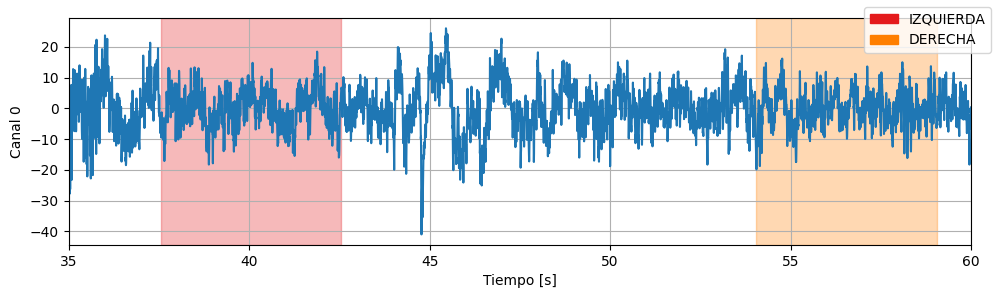

In [161]:
recorte_señal.plot(picks=["2"], show_anotaciones=True)

### **Método filter():** permite aplicar un filtro paso banda a la señal, conservando solo la información contenida entre las frecuencias l_freq y h_freq.

In [162]:
filtrada = recorte_señal.filter(l_freq=20, h_freq=100)

Luego de aplicar el filtrado, se utilizó el método plot() sobre el objeto filtrada para visualizar la señal procesada del canal "2".

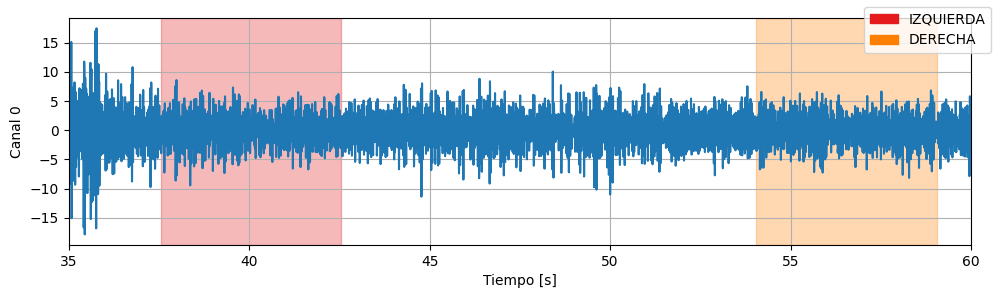

In [ ]:
filtrada.plot(picks=["2"])

---

## **Clase EEGSignal**

> EEGSignal es una subclase de RawSignal especializada para trabajar con señales EEG. Hereda toda su funcionalidad base y agrega herramientas específicas para el análisis EEG

Para instanciar un objeto de la clase `EEGSignal`, primero se prepararon los datos necesarios. Se cargó la matriz de la señal EEG desde un archivo `.npy`, así como un archivo `.csv` con anotaciones de eventos experimentales. También se leyó un archivo `.json` con la información de canales vecinos, utilizada para aplicar la referencia laplaciana.

Luego, se definieron los nombres de los 62 canales y sus respectivos tipos (todos "eeg"), junto con los datos del sujeto (nombre y edad). Con esta información, se creó un objeto `Info` que contiene la descripción completa de la señal, incluyendo frecuencia de muestreo (512 Hz) y relaciones entre canales.

Estos componentes (datos, anotaciones e información del experimento) permiten instanciar correctamente la clase `EEGSignal` y utilizar sus métodos para análisis avanzados.

In [166]:
with open("../2. Datos Prueba/eeg/eeg_vecinos.json", "r") as f:
    vecinos = json.load(f)

canales = range(1,63)
nombre_canales = []
for canal in canales:
    nombre_canales.append(str(canal))
    
tipos_canales = ["eeg"] * len(nombre_canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

# Generamos el objeto Info

info_eeg = Info(experimenter= "Juan", subject_info=sujeto, ch_names=nombre_canales, ch_types=tipos_canales,
                bads=None, description= "Prueba", fm= 512, neighbors=vecinos )

anotaciones_file = Anotaciones(file="../2. Datos Prueba/eeg/eventos_ejemplo.csv")

eeg_data = np.load("../2. Datos Prueba/eeg/eeg_signal.npy")

se instancia un objeto EEGSignal utilizando los datos cargados previamente.

In [167]:
eeg = EEGSignal(data=eeg_data, sfreq=512, info=info_eeg, anotaciones=anotaciones_file, first_samp=0, referencia="canal", canal="1")

Se muestra la señal del canal 0 tras aplicar referencia al canal "1", es decir, se resta la señal del canal "1" a la del canal 0. Esta referencia fue calculada con el método interno _aplicar_referencia_a_canal(). Este método interno se llama automáticamente desde set_reference() cuando se elige la opción "canal". Si el canal no existe, lanza un ValueError. Es útil para eliminar componentes comunes a todos los canales, como ruido o artefactos.

In [168]:
eeg.data_ref[0]

array([0., 0., 0., ..., 0., 0., 0.], shape=(388047,), dtype=float32)

### **Método set_refrence():** Permite modificar la referencia eléctrica utilizada en la señal EEG, una operación fundamental para interpretar correctamente los datos multicanal

Este método recibe el tipo de referencia que se desea aplicar, el cual puede ser `"canal"`, `"promedio"` o `"laplaciano"`, y opcionalmente el nombre de un canal específico si se elige la primera opción.

Internamente, el método llama a uno de tres métodos privados según el tipo de referencia seleccionada. Si se elige `"canal"`, se utiliza `_aplicar_referencia_a_canal`, que resta la señal del canal indicado al resto de los canales. En cambio, si se selecciona `"promedio"`, se invoca `_aplicar_referencia_promedio`, que resta a cada canal el promedio entre todos ellos. Finalmente, si se opta por `"laplaciano"`, se ejecuta `_aplicar_referencia_laplaciana`, que destaca la actividad local de cada canal comparándolo con sus vecinos.

El resultado de esta operación se guarda en el atributo `data_ref`, que almacena la versión referenciada de la señal. En caso de que se ingrese un tipo de referencia inválido, el método lanza un `ValueError`. De este modo, `set_reference` permite adaptar la señal EEG a distintas necesidades analíticas de forma flexible y controlada.

In [169]:
ref = eeg.set_reference(reference="canal", channel="2")
ref.shape
ref[0]

array([   0.5746753,   12.765118 ,   93.63699  , ..., -131.17667  ,
       -139.6159   , -151.46333  ], shape=(388047,), dtype=float32)

Se cambia la referencia de la señal EEG a una referencia *laplaciana*. Al ejecutar `eeg.set_reference("laplaciano")`, se aplica un filtro espacial que resalta la actividad eléctrica local de cada canal, comparándola con la de sus canales vecinos (definidos previamente en el objeto `Info`). Este tipo de referencia es útil para mejorar la localización de fuentes cerebrales activas.

El método interno que utiliza este método es `_aplicar_referencia_laplaciana`, que recorre cada canal, identifica sus vecinos y calcula la diferencia entre la señal del canal y el promedio de sus vecinos. El resultado se almacena en `data_ref` y, al acceder a `ref_laplaciana[0]`, se visualiza la señal laplaciana del primer canal de la matriz.

In [170]:
ref_laplaciana = eeg.set_reference("laplaciano")
ref_laplaciana[0]

array([   0.3132112,    5.108612 ,   33.645447 , ..., -134.44702  ,
       -142.15036  , -153.25374  ], shape=(388047,), dtype=float32)

Se cambia la referencia de la señal EEG a una referencia **promedio** mediante el método `set_reference(reference="promedio")`. Esto significa que a cada canal se le resta, muestra a muestra, el promedio de todos los canales en ese instante, lo que ayuda a reducir el ruido común compartido entre ellos y mejora la interpretación de la actividad relativa.

Internamente, se utiliza el método `_aplicar_referencia_promedio`, que calcula el promedio por columna (es decir, en el tiempo) y genera una nueva matriz referenciada, almacenada en `data_ref`. Al consultar `ref_promedio.shape`, se obtiene la forma de la matriz referenciada, y `ref_promedio[0]` devuelve la señal del primer canal con esta referencia aplicada.

In [171]:
ref_promedio = eeg.set_reference(reference="promedio")
ref_promedio.shape
ref_promedio[0]

array([   1.493839,   26.415298,  181.00632 , ..., -131.14218 ,
       -136.10907 , -145.36543 ], shape=(388047,), dtype=float32)

### **Método espectro_frecuencias():** Calcula la densidad espectral de potencia (PSD) de uno o más canales de EEG utilizando el algoritmo de Welch, que es robusto y comúnmente usado en análisis de señales fisiológicas.

Este método permite analizar cómo se distribuye la potencia de la señal en distintas frecuencias, lo que es útil para identificar ritmos cerebrales como alfa, beta, delta, etc.

Internamente, el método usa scipy.signal.welch para calcular las componentes frecuenciales y convierte los resultados a decibelios (dB). Si plot=True, llama a un método interno _plot_spectrum, que genera un gráfico para cada canal seleccionado mostrando su contenido espectral entre fmin y fmax.

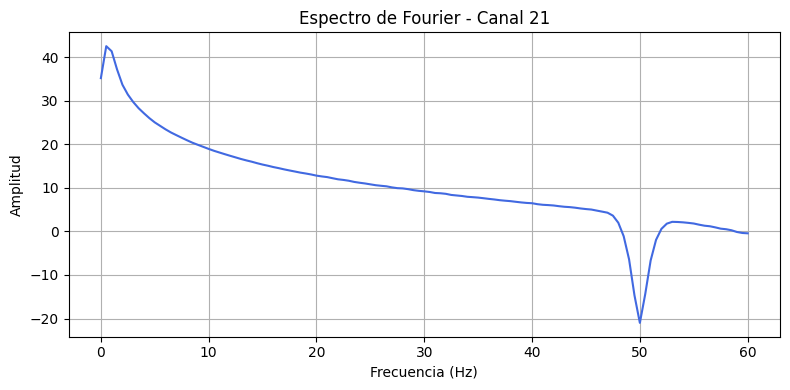

In [172]:
frec, espectro = eeg.espectro_frecuencias(picks=["21"],plot=True, fmin=0, fmax=60)

In [ ]:
eeg_filtrada = eeg.filter(l_freq=0.1, h_freq=40)

In [ ]:
eeg_filtrada_recortada = eeg_filtrada.crop(tmin=20, tmax=21)

In [ ]:
eeg_filtrada_recortada.plot(picks=["3"])

In [ ]:
e = eeg_filtrada_recortada.plot_hilbert_transform(picks=["3"])

In [ ]:
eeg_filtrada_recortada.plot_time_frequency(canal="22", fmin= 4,fmax=8, start_time=20, end_time=25, absoluto=True)

## **Clase ECGSignal**

## **Clase EMGSignal**

In [ ]:
# Cargar datos
emg_data = np.load("../2. Datos Prueba/emg/emg.npy")

In [ ]:
emg_data.shape

In [ ]:
nombre_canales = ["1"]
    
tipos_canales = ["emg"] * len(nombre_canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

# Generamos el objeto Info

info_emg = Info(experimenter= "Juan", subject_info=sujeto, ch_names=nombre_canales, ch_types=tipos_canales,
                bads=None, description= "Prueba", fm= 512)

anotaciones_file = Anotaciones(file="../2. Datos Prueba/emg/eventos_emg.csv")

In [ ]:
emg = EMGSignal(emg_data, sfreq=1000, info=info_emg, anotaciones=anotaciones_file, umbral_microv=2000)

In [ ]:
emg.plot_activaciones(canal="1",start_time=20, end_time=40)

In [ ]:
emg.plot_spectrogram(canal="1", start_time=20, end_time=30)

In [ ]:
emg.plot_hilbert(picks=["1"], tmin=20, tmax= 40)

In [ ]:
emg.plot(show_anotaciones=True)